# Multiclass logistic regression tutorial

In this tutorial, we solve a *classification* problem with $K = 3$ classes with multiclass logistic regression, trained by gradient descent.

We have a training set of $N$ inputs with two features each, $\mathbf{x}_n \in \mathbb{R}^D$ with $D = 2$, and one label each, $y_n \in \{0, 1, \dots, K - 1\}$, for $n = 1, \dots, N$.
(We number the classes from $0$, as Python does; the lecture numbers them from $1$.)
Multiclass logistic regression computes one linear score per class, the *logit* $z_{n,k}$, and turns the $K$ logits of an input into probabilities with the *softmax* function:

$$\hat{y}_{n,k} = p(y_n = k \mid \mathbf{x}_n, \boldsymbol{\theta}) = \mathrm{softmax}(\mathbf{z}_n)_k = \frac{\mathrm{e}^{z_{n,k}}}{\sum_{j=0}^{K-1} \mathrm{e}^{z_{n,j}}}.$$

As in the lecture, $\boldsymbol{\theta}$ stands for the learnable parameters of the model, gathered in a single vector: the objective, its gradient and the gradient descent update are $J(\boldsymbol{\theta})$, $\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$ and $\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$.
That vector is the abstraction: whatever the parameters of a model happen to be, they form one $\boldsymbol{\theta}$, and gradient descent moves it.
Here we lay the very same numbers out as a matrix $\mathbf{W}$, simply because the expressions come out more convenient that way: all predictions are then a single matrix product, and so is the gradient.
Neural networks will be the same story, with the parameters $\boldsymbol{\theta}$ spread over many matrices.

As in the logistic regression tutorial, we append a $1$ to every input.
The bias of a class then becomes the last entry of that class's parameter vector and is treated like any other weight:

$$\mathbf{w}_k = \begin{pmatrix} w_{1,k} \\ w_{2,k} \\ b_k \end{pmatrix} \in \mathbb{R}^{D + 1}, \qquad
\tilde{\mathbf{x}}_n = \begin{pmatrix} x_{n,1} \\ x_{n,2} \\ 1 \end{pmatrix} \in \mathbb{R}^{D + 1}, \qquad
z_{n,k} = \mathbf{w}_k^\top \tilde{\mathbf{x}}_n.$$

Binary logistic regression got by with a single such vector, one weight per feature plus a bias; multiclass logistic regression needs one of them per class.
One per row, the $K$ of them form the *weight matrix* $\mathbf{W}$, and stacking the bias-augmented feature vectors row by row gives the *bias-augmented data matrix* $\tilde{\mathbf{X}}$:

$$\mathbf{W} = \begin{pmatrix} \mathbf{w}_0^\top \\ \vdots \\ \mathbf{w}_{K-1}^\top \end{pmatrix} \in \mathbb{R}^{K \times (D + 1)}, \qquad
\tilde{\mathbf{X}} = \begin{pmatrix}
x_{1,1} & x_{1,2} & 1\\
x_{2,1} & x_{2,2} & 1\\
\vdots & \vdots & \vdots\\
x_{N,1} & x_{N,2} & 1
\end{pmatrix} \in \mathbb{R}^{N \times (D + 1)}.$$

The parameter vector $\boldsymbol{\theta}$ of the model is this matrix with its rows stacked on top of each other:

$$\boldsymbol{\theta} = \begin{pmatrix} \mathbf{w}_0 \\ \mathbf{w}_1 \\ \vdots \\ \mathbf{w}_{K-1} \end{pmatrix} \in \mathbb{R}^{K (D + 1)},$$

which is what `W.flatten()` computes.
Binary logistic regression is the special case of a single row, where the stack is that row itself.
Nothing about the learning changes: $\nabla_{\boldsymbol{\theta}} J$ is $\nabla_{\mathbf{W}} J$ with its rows stacked in the same way, so a gradient descent step on $\boldsymbol{\theta}$ and one on $\mathbf{W}$ do the same thing.

With one row of $\mathbf{W}$ per class, the logits of one example are $\mathbf{z}_n = \mathbf{W} \tilde{\mathbf{x}}_n$, and the logits of all examples come out of a single matrix product, without a loop over the examples:

$$\hat{\mathbf{Y}} = \mathrm{softmax}(\tilde{\mathbf{X}} \mathbf{W}^\top) \in (0, 1)^{N \times K},$$

where the softmax is applied row by row.
This is also how PyTorch lays out a linear layer, whose weight matrix has one row per output and which computes exactly this product.

With $K$ classes, a single number per example is no longer enough to describe a label: the model predicts $K$ probabilities per example, so we write the labels as $K$ numbers per example too, in *one-hot* encoding.
Row $n$ of the label matrix $\mathbf{Y}$ has a one in the column of the correct class and zeros everywhere else:

$$\mathbf{Y} = \begin{pmatrix}
0 & 0 & 1\\
0 & 1 & 0\\
\vdots & \vdots & \vdots\\
0 & 0 & 1\\
1 & 0 & 0
\end{pmatrix} \in \{0, 1\}^{N \times K}.$$

Here the first example belongs to class 2, the second one to class 1, and the last one to class 0.
This is the output axis of size $K$ that the logistic regression tutorial could drop, because binary classification needs only a single probability per example.

As objective, we use the categorical cross-entropy (CCE) between the labels and the predicted probabilities (also called the negative log-likelihood, see lecture 1):

$$J(\mathbf{W}) = -\frac{1}{N} \sum_{n=1}^N \sum_{k=0}^{K-1} y_{n,k} \ln(\hat{y}_{n,k}).$$

It is small when the predicted probabilities are close to their labels.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb


# Set Matplotlib backend to `inline` to display the figure below the cell that produced it
%matplotlib inline

In [2]:
def softmax(Z):
    """Turn each row of logits into probabilities with the softmax function.

    Args:
        Z: Matrix of logits, of shape (N, K).

    Returns:
        The probabilities, of shape (N, K). Each row is non-negative and sums to one.
    """
    # The softmax only depends on differences of logits, so we may subtract the row maximum.
    # This avoids an overflow of `np.exp` for large logits, without changing the result.
    e_Z = np.exp(Z - Z.max(axis=1, keepdims=True))
    return e_Z / e_Z.sum(axis=1, keepdims=True)


def multiclass_logistic_model(X_tilde, W):
    """Evaluate the multiclass logistic regression model.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        W: Weight matrix of shape (K, D + 1), one row per class.

    Returns:
        The predicted class probabilities, of shape (N, K).
    """
    return softmax(X_tilde @ W.T)

## 1. Dataset creation

Let's draw some samples for training and test.
Each class has its own Gaussian, which models imperfect observations of three prototypes.

In [3]:
# Sizes (see the notation of lecture 1)
D = 2  # input features per example
K = 3  # classes
N_per_class = 100  # examples per class, so each set has K * N_per_class examples

rng = np.random.default_rng(42)


def get_dataset(N=N_per_class, mus=((0, 0), (2, 2), (2, -1)), var=0.45):
    """Create a dataset by drawing N samples per class from one Gaussian per class.

    Args:
        N: Number of examples per class.
        mus: Centers of the classes, one per class.
        var: Variance of all Gaussians along each feature.

    Returns:
        The data matrix of shape (K N, D) and the one-hot label matrix of shape (K N, K).
    """
    cov = var * np.eye(D)

    Xs, Ys = [], []
    for k, mu in enumerate(mus):
        # Class k samples
        Xs.append(rng.multivariate_normal(mu, cov, N))

        # One-hot representation of their labels: a one in column k
        Y_k = np.zeros((N, len(mus)))
        Y_k[:, k] = 1
        Ys.append(Y_k)

    return np.concatenate(Xs), np.concatenate(Ys)


def augment(X):
    """Append the column of ones that implements the bias terms (see lecture 3).

    Args:
        X: Data matrix of shape (N, D).

    Returns:
        The bias-augmented data matrix, of shape (N, D + 1).
    """
    return np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)


def plot_data(X, Y, xlim=(-2, 4.5), ylim=(-3, 4), legend=True):
    """Draw a scatter plot of the data, colored by label.

    Args:
        X: Data matrix of shape (N, D).
        Y: One-hot label matrix of shape (N, K).
        xlim: Range of the horizontal axis.
        ylim: Range of the vertical axis.
        legend: Whether to add a legend (off for all but one panel of a grid).
    """
    for k in range(Y.shape[1]):
        plt.scatter(X[Y[:, k] == 1, 0], X[Y[:, k] == 1, 1], label=f"class {k}")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    if legend:
        plt.legend(loc="upper left")

X_train has shape (300, 2), Y_train has shape (300, 3)
X_test has shape (300, 2), Y_test has shape (300, 3)
After augmentation, X_tilde_train has shape (300, 3)
One row of Y_train per class:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


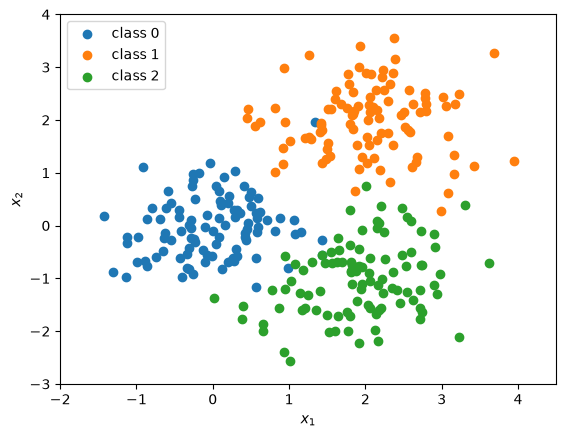

In [4]:
# Draw the training and test set
X_train, Y_train = get_dataset()
X_test, Y_test = get_dataset()

# Append the column of ones to both data matrices
X_tilde_train, X_tilde_test = augment(X_train), augment(X_test)

print(f"X_train has shape {X_train.shape}, Y_train has shape {Y_train.shape}")
print(f"X_test has shape {X_test.shape}, Y_test has shape {Y_test.shape}")
print(f"After augmentation, X_tilde_train has shape {X_tilde_train.shape}")
print(f"One row of Y_train per class:\n{Y_train[::N_per_class]}")

# Plot the training samples
plot_data(X_train, Y_train)

**Remark**:
As you can see, we sample the data from three Gaussians.
In a real machine learning problem, however, we have **no access** to the **data generation** process: think of the hidden process that produces images or speech signals.
The learning algorithm only sees the samples, never the process that produced them.

## 2. Training with gradient descent

To perform gradient descent, we need the gradient of the objective (see lecture 3).
It is again *error times input*:

$$\nabla_{\mathbf{W}} J(\mathbf{W}) = \frac{1}{N} \big( \hat{\mathbf{Y}} - \mathbf{Y} \big)^\top \tilde{\mathbf{X}} \in \mathbb{R}^{K \times (D + 1)}.$$

It has the shape of $\mathbf{W}$, as every gradient must.
In the vector notation of the introduction, $\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta})$ is this matrix with its rows stacked, in the same way as $\boldsymbol{\theta}$ itself.
We use the fully vectorized form.
Remember that in machine learning we avoid *for loops* as much as possible when implementing a model: loops are slow, while matrix multiplications are easily parallelized.

One update of the parameters goes into a function, so that the training loop below only has to call it once per epoch.

In [5]:
def cce(Y, Y_hat):
    """Return the mean categorical cross-entropy between labels and predictions.

    Args:
        Y: One-hot label matrix of shape (N, K).
        Y_hat: Matrix of predicted class probabilities, of shape (N, K).

    Returns:
        The mean categorical cross-entropy (a scalar).
    """
    # `np.log` is the natural logarithm
    return -(Y * np.log(Y_hat)).sum(axis=1).mean()


def accuracy(Y, Y_hat):
    """Return the fraction of examples that are classified correctly.

    Args:
        Y: One-hot label matrix of shape (N, K).
        Y_hat: Matrix of predicted class probabilities, of shape (N, K).

    Returns:
        The accuracy, a number between 0 and 1.
    """
    # The predicted class is the one with the highest probability
    return (Y_hat.argmax(axis=1) == Y.argmax(axis=1)).mean()


def gd_step(X_tilde, Y, W, lr):
    """Perform one gradient descent step on the categorical cross-entropy.

    Args:
        X_tilde: Bias-augmented data matrix of the training set, of shape (N, D + 1).
        Y: One-hot label matrix of the training set, of shape (N, K).
        W: Current weight matrix of shape (K, D + 1).
        lr: Learning rate (a scalar).

    Returns:
        The updated weight matrix, of shape (K, D + 1).
    """
    Y_hat = multiclass_logistic_model(X_tilde, W)
    grad = (Y_hat - Y).T @ X_tilde / len(Y)
    return W - lr * grad


# The light variants of the `tab:blue`, `tab:orange` and `tab:green` that the scatter plot uses
# for the three classes, so that the data points stay clearly visible on top of the shading
class_colors = np.array([to_rgb(color) for color in ["#aec7e8", "#ffbb78", "#98df8a"]])


def plot_boundaries(W, xlim=(-2, 4.5), ylim=(-3, 4)):
    """Shade the plane by the class that multiclass logistic regression predicts.

    Every point gets the color of its predicted class, faded towards white by how close the
    two leading probabilities are: the paler the shading, the less certain the model. The
    dashed lines are the decision boundaries, where two classes are equally likely.

    Args:
        W: Weight matrix of shape (K, D + 1).
        xlim: Range of the horizontal axis.
        ylim: Range of the vertical axis.
    """
    x1, x2 = np.meshgrid(np.linspace(*xlim, 200), np.linspace(*ylim, 200))
    Z = augment(np.column_stack([x1.ravel(), x2.ravel()])) @ W.T  # the logits of the grid
    P = softmax(Z)

    # Fade the color of the predicted class towards white by the gap between the two largest
    # probabilities, which is 1 where the model is certain and 0 where two classes tie
    ranked = np.sort(P, axis=1)
    certainty = (ranked[:, -1] - ranked[:, -2])[:, None]
    rgb = 1 - certainty * (1 - class_colors[P.argmax(axis=1)])
    plt.imshow(rgb.reshape(*x1.shape, 3), extent=(*xlim, *ylim), origin="lower", aspect="auto")

    # Two classes are equally likely where their logits are equal, which is a straight line.
    # Only the part of it where no third class scores higher is a decision boundary.
    winner = Z.argmax(axis=1)
    for k in range(K):
        for j in range(k + 1, K):
            tie = np.where((winner == k) | (winner == j), Z[:, k] - Z[:, j], np.nan)
            plt.contour(
                x1, x2, tie.reshape(x1.shape), levels=[0.0],
                colors="k", linewidths=1, linestyles="--"
            )

epoch    0: train loss = 0.5331, test loss = 0.6359
epoch    1: train loss = 0.3499, test loss = 0.4406
epoch    2: train loss = 0.2553, test loss = 0.3380
epoch    3: train loss = 0.2095, test loss = 0.2879
epoch    5: train loss = 0.1690, test loss = 0.2433
epoch    8: train loss = 0.1411, test loss = 0.2125
epoch   12: train loss = 0.1236, test loss = 0.1927
epoch   20: train loss = 0.1093, test loss = 0.1757
epoch   35: train loss = 0.1011, test loss = 0.1647
epoch   60: train loss = 0.0976, test loss = 0.1594


epoch  150: train loss = 0.0954, test loss = 0.1590
epoch  600: train loss = 0.0946, test loss = 0.1649


after 3000 epochs: train loss = 0.0945, test loss = 0.1665
                    train accuracy = 0.9667, test accuracy = 0.9500
W =
[[-2.2071  1.1633  4.7248]
 [ 1.6208  5.7726 -3.8274]
 [ 2.5863 -2.9359 -2.1975]]


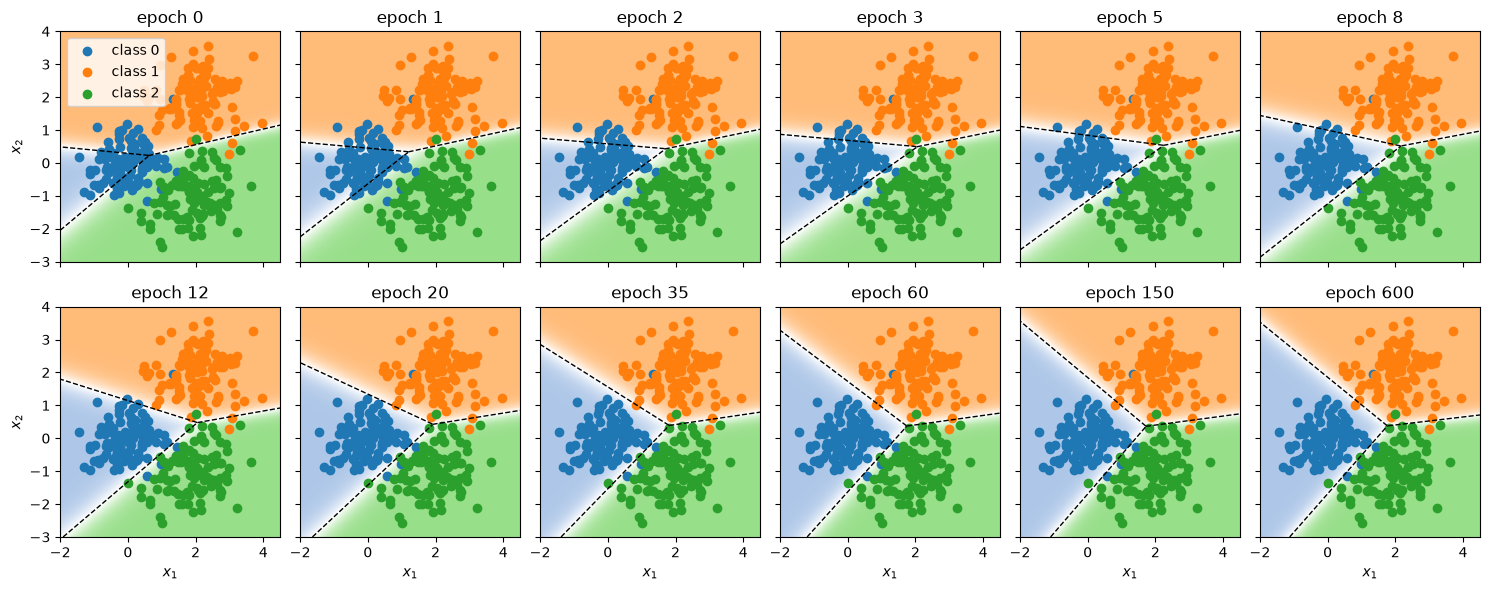

In [6]:
# Initial values (deliberately poor)
W = np.array([[1.5, -0.5, 1.0], [0.0, 6.5, -1.0], [0.5, -2.0, -1.3]])

# Hyperparameters
N_epochs = 3000
lr = 3.0

# The boundaries swing in the first epochs and then only sharpen, so we report and snapshot
# them on a roughly doubling schedule, one entry per panel of the grid below
report_epochs = [0, 1, 2, 3, 5, 8, 12, 20, 35, 60, 150, 600]

# The snapshots share their axes, so that the panels can be compared directly
fig, axes = plt.subplots(2, 6, figsize=(15, 6), sharex=True, sharey=True)
panels = axes.flatten()

train_loss, train_acc = [], []
test_loss, test_acc = [], []
for epoch in range(N_epochs):
    # one gradient descent update
    W = gd_step(X_tilde_train, Y_train, W, lr)

    # compute the training and test metrics (just to monitor)
    Y_hat_train = multiclass_logistic_model(X_tilde_train, W)
    Y_hat_test = multiclass_logistic_model(X_tilde_test, W)
    train_loss.append(cce(Y_train, Y_hat_train))
    test_loss.append(cce(Y_test, Y_hat_test))
    train_acc.append(accuracy(Y_train, Y_hat_train))
    test_acc.append(accuracy(Y_test, Y_hat_test))

    if epoch in report_epochs:
        print(f"epoch {epoch:4d}: train loss = {train_loss[-1]:.4f}, test loss = {test_loss[-1]:.4f}")

        # draw the training data with the current decision regions into the next panel
        plt.sca(panels[report_epochs.index(epoch)])
        plot_boundaries(W)
        plot_data(X_train, Y_train, legend=epoch == 0)
        plt.title(f"epoch {epoch}")

for panel in panels:
    panel.label_outer()  # keep the axis labels on the outer panels only
fig.tight_layout()

print(f"after {N_epochs} epochs: train loss = {train_loss[-1]:.4f}, test loss = {test_loss[-1]:.4f}")
print(f"{20 * ' '}train accuracy = {train_acc[-1]:.4f}, test accuracy = {test_acc[-1]:.4f}")
print(f"W =\n{np.round(W, 4)}")

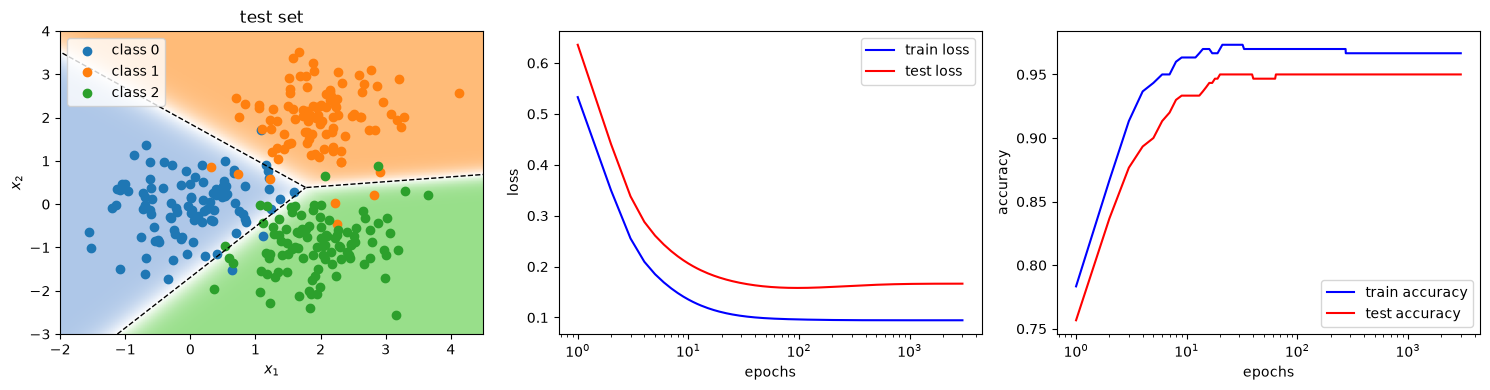

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: the test data with the final decision regions
plt.sca(axes[0])  # `plot_boundaries` and `plot_data` draw into the current axes
plot_boundaries(W)
plot_data(X_test, Y_test)
axes[0].set_title("test set")

# Middle and right: the training curves, on a logarithmic epoch axis, as most of the
# progress happens in the first epochs
epochs = np.arange(1, N_epochs + 1)
for panel, (train, test, name) in zip(
    axes[1:], [(train_loss, test_loss, "loss"), (train_acc, test_acc, "accuracy")]
):
    panel.plot(epochs, train, color="blue", label=f"train {name}")
    panel.plot(epochs, test, color="red", label=f"test {name}")
    panel.set_xscale("log")
    panel.set_xlabel("epochs")
    panel.set_ylabel(name)
    panel.legend()

fig.tight_layout()

The algorithm starts from a bad solution, but gradient descent quickly improves it.
The final regions also classify the test data well.
Note that the accuracy saturates long before the loss does: once a boundary lies between two clouds, moving it further changes no prediction, while the objective keeps rewarding more confident probabilities.
Pushed far enough, this confidence starts to cost us: the test loss passes through a minimum and grows again, while the training loss keeps falling, a first glimpse of overfitting (see lecture 2).

## 3. Multiclass logistic regression with scikit-learn

scikit-learn's `LogisticRegression` covers the multiclass case as well: with more than two classes, it fits multinomial (softmax) logistic regression automatically.
As in the logistic regression tutorial, its argument `C` is the *inverse* regularization strength, which multiplies the loss rather than the penalty, so `C=np.inf` switches the L2 penalty off and leaves our plain categorical cross-entropy.

Comparing the two solutions takes one more step here.
The softmax only looks at *differences* of logits: adding the same vector to every row of $\mathbf{W}$ adds the same number to all $K$ logits of every example, and therefore leaves every prediction unchanged.
(This is the same shift invariance that lets our `softmax` subtract the row maximum.)
Without the penalty, the objective thus has infinitely many minimizers, and two solutions can only be compared after fixing the shift.
We fix it by subtracting the mean over the classes, which makes every column of $\mathbf{W}$ sum to zero.

largest change of a weight:      1.3333
largest change of a probability: 3.33e-16
our W, centered:
[[-2.8737 -0.17    5.1582]
 [ 0.9541  4.4392 -3.394 ]
 [ 1.9196 -4.2692 -1.7641]]
scikit-learn's W, centered:
[[-2.8735 -0.1699  5.1571]
 [ 0.9537  4.4352 -3.391 ]
 [ 1.9198 -4.2653 -1.7661]]


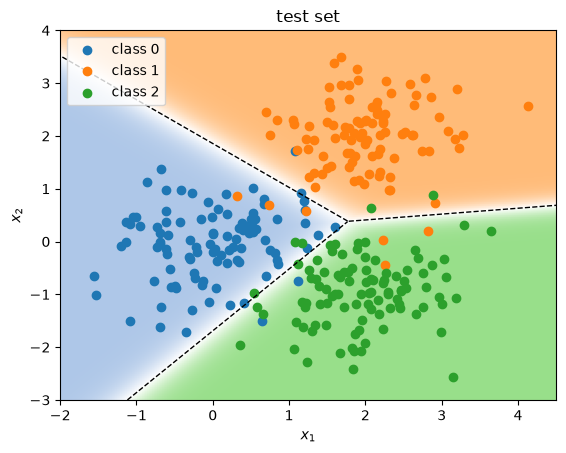

In [8]:
from sklearn.linear_model import LogisticRegression

# scikit-learn takes the data matrix without the column of ones and adds the intercepts itself,
# expects the labels as class indices rather than one-hot, and with `C=np.inf` it minimizes the
# same objective as we do
classifier = LogisticRegression(C=np.inf).fit(X_train, Y_train.argmax(axis=1))
# `coef_` is already (K, D) and `intercept_` is (K,), the layout we use here
W_sklearn = np.column_stack([classifier.coef_, classifier.intercept_])


def center(W):
    """Shift a weight matrix so that its columns sum to zero, without changing its predictions.

    Args:
        W: Weight matrix of shape (K, D + 1).

    Returns:
        The shifted weight matrix, of shape (K, D + 1).
    """
    return W - W.mean(axis=0, keepdims=True)


# Centering moves the weights, but leaves every predicted probability where it was
Y_hat = multiclass_logistic_model(X_tilde_test, W)
Y_hat_centered = multiclass_logistic_model(X_tilde_test, center(W))
print(f"largest change of a weight:      {np.abs(center(W) - W).max():.4f}")
print(f"largest change of a probability: {np.abs(Y_hat_centered - Y_hat).max():.2e}")
assert np.allclose(Y_hat, Y_hat_centered), "Centering changed the predictions!"

# The two raw weight matrices differ by such a shift, so we compare the centered ones
print(f"our W, centered:\n{np.round(center(W), 4)}")
print(f"scikit-learn's W, centered:\n{np.round(center(W_sklearn), 4)}")

# Both minimize the same objective, so both must land on the same parameters (up to the shift
# above, and up to the accuracy with which gradient descent approaches the minimum)
assert np.allclose(center(W), center(W_sklearn), atol=1e-2), (
    "scikit-learn found a different solution!"
)

# Plot the test data with the scikit-learn decision regions
plot_boundaries(W_sklearn)
plot_data(X_test, Y_test)
plt.title("test set");

## Conclusion

We have trained multiclass logistic regression in two ways, with our own gradient descent and with scikit-learn, and checked that both find the same parameters once scikit-learn's regularization is off.
The model is the binary one with $K$ parameter vectors instead of one and the softmax in place of the sigmoid, and the gradient keeps the same *error times input* form.
Its decision regions are still bounded by straight lines, so the same limitation applies: if the classes are not linearly separable, we need a feature transformation, as at the end of the logistic regression tutorial, or a model that learns one, which is what neural networks do.